# Chapter 07 — Dense Retrieval, ANN/HNSW, and Quantization

*Where we are:* the second retrieval arm — **semantic** matching — plus the indexing that makes
it scale.

```
chunks →[ embeddings → brute-force → HNSW → quantization ]→ fusion → rerank
```

Embeddings map text to a vector so related passages are close **even without shared words** —
repairing BM25's vocabulary-mismatch weakness. All inference here is **CPU-pinned and
deterministic**.

In [1]:
# === Chapter 07 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

# After you push this repo to GitHub, put its URL here (one edit works for every chapter):
REPO_URL = ""   # e.g. "https://github.com/<you>/patent-rag-masterclass"
NEED_OCR = False
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if REPO_URL:
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, target], check=True)
        else:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 07 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 07 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


## 23. Embeddings & similarity

An embedding model maps text → $\mathbf{v}\in\mathbb{R}^d$. With **L2-normalized** vectors,
**cosine similarity** equals the dot product:

$$\cos(\mathbf{a},\mathbf{b})=\frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}\;\xrightarrow{\;\lVert\mathbf{a}\rVert=\lVert\mathbf{b}\rVert=1\;}\;\mathbf{a}\cdot\mathbf{b}$$

We use `all-MiniLM-L6-v2` (384-d): a reproducible, CPU-friendly baseline. bge-small / e5-small /
gte-small are stronger current upgrades (they need query/passage prefixes).

In [2]:
from patentrag.dense import embed, cosine
import numpy as np
probe = [
    "approximate nearest neighbor search over dense vectors",
    "finding the closest vectors quickly in a large index",   # paraphrase — no shared content words
    "a recipe for tomato basil soup",                         # unrelated
]
V = embed(probe)
print("embedding dim:", V.shape[1])
print(f"cos(ANN, paraphrase) = {float(V[0] @ V[1]):.3f}   (semantically close)")
print(f"cos(ANN, soup)       = {float(V[0] @ V[2]):.3f}   (unrelated)")

C:\Users\rsalehin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8534.61it/s]

embedding dim: 384
cos(ANN, paraphrase) = 0.757   (semantically close)
cos(ANN, soup)       = 0.050   (unrelated)


## 24. Brute-force dense retrieval

Exact cosine search is a single matrix multiply: $\text{scores} = M\,\mathbf{q}$ over normalized
embeddings. We retrieve over the corpus chunk embeddings (`embeddings` artifact).

In [3]:
import pandas as pd
from patentrag.dense import DenseRetriever
emb = bs.ensure("embeddings")
chunks = bs.ensure("chunks"); by_id = {c.chunk_id: c for c in chunks}
dense = DenseRetriever(emb["chunk_ids"], emb["matrix"])
q = "how do you keep millions of feature vectors and find close ones fast?"
rows = [{"pub": by_id[c].publication_number, "section": by_id[c].section[:16], "cos": round(s, 3),
         "text": by_id[c].text[:52]} for c, s in dense.search(q, 6)]
pd.DataFrame(rows)

,pub,section,cos,text
0,US11714853B2,BACKGROUND,0.663,Many distributed and fog computing application...
1,US11714853B2,EMBODIMENTS OF T,0.649,"Accordingly, this disclosure presents various ..."
2,US11714853B2,EMBODIMENTS OF T,0.636,"In the illustrated embodiment, a nearest neigh..."
3,US11714853B2,EMBODIMENTS OF T,0.630,"As an example, using traditional data storage ..."
4,US11714853B2,EMBODIMENTS OF T,0.628,"For example, there are various “in-memory” lib..."
5,US11714853B2,EMBODIMENTS OF T,0.627,The described feature vector management system...


### Lexical vs semantic — a query where dense wins

For a paraphrased query with little lexical overlap, BM25 struggles while dense retrieval finds
the right patent by meaning.

In [4]:
bm25 = bs.ensure("bm25_index")
paraphrase = "let shoppers get product suggestions instantly from learned taste vectors"
target = "US11113744B2"   # personalized recommendations via deep embeddings
def first_rank_of_doc(results):
    for r, (cid, _) in enumerate(results, 1):
        if by_id[cid].document_id == target:
            return r
    return None
print("query:", paraphrase)
print("  BM25  first rank of target doc:", first_rank_of_doc(bm25.search(paraphrase, 50)))
print("  Dense first rank of target doc:", first_rank_of_doc(dense.search(paraphrase, 50)))

query: let shoppers get product suggestions instantly from learned taste vectors
  BM25  first rank of target doc: 19
  Dense first rank of target doc: 1


## 25–26. Exact NN vs Approximate NN — HNSW

Brute force is $O(N)$ per query — fine for thousands, ruinous for millions. **HNSW**
(Hierarchical Navigable Small World) builds a layered proximity graph and navigates it greedily
in ~$O(\log N)$. Knobs:

- **`M`** — links per node (graph degree): higher = better recall, more memory.
- **`efConstruction`** — candidate breadth at build time: higher = better graph, slower build.
- **`efSearch`** — candidate breadth at query time: the **recall ↔ latency** dial.

On our small corpus HNSW is essentially exact:

In [5]:
from patentrag.dense import recall_at_k
hnsw = bs.ensure("ann_index")
qv = emb["matrix"][7]
exact = set(dense.exact_topk(qv, 10))
for ef in [8, 16, 32, 64]:
    approx = {emb["chunk_ids"].index(cid) for cid, _ in hnsw.search(qv, 10, ef_search=ef)}
    print(f"  efSearch={ef:3d}  recall@10 vs exact = {recall_at_k(list(approx), list(exact)):.2f}")
print(f"\n(With only {len(emb['chunk_ids'])} vectors HNSW is trivially exact — the interesting")
print(" recall/latency regime needs many more vectors, which we simulate next.)")

  efSearch=  8  recall@10 vs exact = 1.00
  efSearch= 16  recall@10 vs exact = 1.00
  efSearch= 32  recall@10 vs exact = 1.00
  efSearch= 64  recall@10 vs exact = 1.00

(With only 1044 vectors HNSW is trivially exact — the interesting
 recall/latency regime needs many more vectors, which we simulate next.)


### Recall vs latency — the real ANN regime (synthetic vectors)

Our patent corpus is too small to *exhibit* the trade-off, so we build a **synthetic** index of
50,000 random 384-d vectors (clearly labelled — not patent data) to show how `efSearch` trades
recall against latency against an exact FAISS baseline.

In [6]:
import faiss, time
bs.set_seeds()
rng = np.random.default_rng(0)
N, dim = 50000, 384
X = rng.standard_normal((N, dim)).astype("float32"); faiss.normalize_L2(X)
Q = rng.standard_normal((300, dim)).astype("float32"); faiss.normalize_L2(Q)

flat = faiss.IndexFlatL2(dim); flat.add(X)
_, gt = flat.search(Q, 10)   # exact ground truth

hn = faiss.IndexHNSWFlat(dim, 32); hn.hnsw.efConstruction = 200; hn.add(X)
rows = []
for ef in [8, 16, 32, 64, 128, 256]:
    hn.hnsw.efSearch = ef
    t0 = time.perf_counter(); _, I = hn.search(Q, 10); ms = (time.perf_counter()-t0)/len(Q)*1000
    rec = np.mean([len(set(I[i]) & set(gt[i]))/10 for i in range(len(Q))])
    rows.append({"efSearch": ef, "recall@10": round(float(rec), 3), "ms/query": round(ms, 3)})
recdf = pd.DataFrame(rows); recdf

,efSearch,recall@10,ms/query
0,8,0.060,0.015
1,16,0.102,0.024
2,32,0.180,0.039
3,64,0.299,0.076
4,128,0.473,0.122
5,256,0.687,0.224


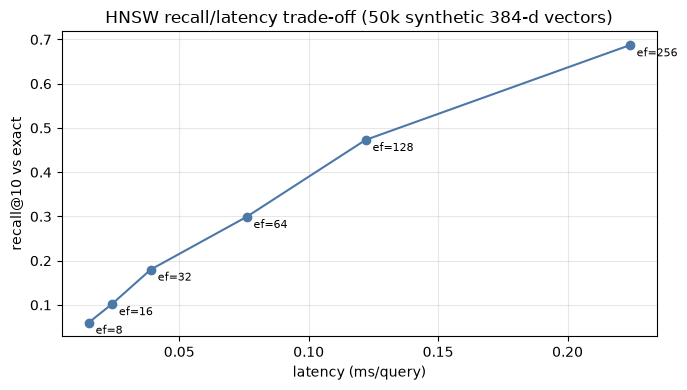

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recdf["ms/query"], recdf["recall@10"], "o-", color="#4C78A8")
for _, r in recdf.iterrows():
    ax.annotate(f"ef={int(r['efSearch'])}", (r["ms/query"], r["recall@10"]), fontsize=8,
                textcoords="offset points", xytext=(5, -8))
ax.set_xlabel("latency (ms/query)"); ax.set_ylabel("recall@10 vs exact")
ax.set_title("HNSW recall/latency trade-off (50k synthetic 384-d vectors)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 27. Why quantization exists — the memory wall

$$\text{memory} = N \times d \times \text{bytes/scalar}$$

At patent scale (100M+ vectors) float32 is enormous. Compress the *scalars* (float16, int8) or
the *vectors* (product quantization).

In [8]:
from patentrag.dense import memory_report
mr = memory_report(100_000_000, emb["dim"])
pd.DataFrame([{"encoding": k.replace("_GB",""), "GB for 100M×384": round(v, 1)} for k, v in mr.items()])

,encoding,GB for 100M×384
0,float32,153.6
1,float16,76.8
2,int8,38.4
3,pq_m48,4.8


## 28. Product Quantization / compressed search

**PQ** splits each vector into $m$ sub-vectors, learns a codebook per subspace, and stores each
vector as $m$ byte-codes — a huge memory cut at some accuracy cost. **Scalar int8** quantizes
each dimension to a byte (4× smaller, near-exact). We measure both on the real corpus.

In [9]:
from patentrag.dense import PQIndex, ScalarInt8Index
ids, mat = emb["chunk_ids"], emb["matrix"]
pq = PQIndex(emb["dim"], m=48, nbits=8).train_add(ids, mat)
sc = ScalarInt8Index(emb["dim"]).train_add(ids, mat)
qv = mat[7]; exact = set(dense.exact_topk(qv, 10))
pq_r = recall_at_k([i for i in pq.search(qv, 10)], list(exact))
sc_r = recall_at_k([i for i in sc.search(qv, 10)], list(exact))
pd.DataFrame([
    {"index": "float32 flat (exact)", "bytes/vector": emb["dim"]*4, "recall@10": 1.00},
    {"index": "scalar int8",          "bytes/vector": sc.bytes_per_vector, "recall@10": round(sc_r, 2)},
    {"index": "product quant (m=48)", "bytes/vector": pq.bytes_per_vector, "recall@10": round(pq_r, 2)},
])

,index,bytes/vector,recall@10
0,float32 flat (exact),1536,1.0
1,scalar int8,384,1.0
2,product quant (m=48),48,0.9


**Production implications.** Below ~1M vectors, exact or int8-flat is simplest and accurate.
Beyond that, HNSW (tune `M`/`efSearch` for your recall target) and PQ/IVF-PQ trade memory for a
little recall — always **measure recall against an exact baseline** before shipping a
compression. GPU helps build/search but is never required.

## Chapter invariants

In [10]:
assert emb["matrix"].shape == (len(emb["chunk_ids"]), emb["dim"])
assert float(V[0] @ V[1]) > float(V[0] @ V[2])                       # paraphrase closer than unrelated
assert recdf["recall@10"].iloc[-1] >= recdf["recall@10"].iloc[0]     # recall rises with efSearch
assert mr["float32_GB"] > mr["int8_GB"] > mr["pq_m48_GB"]
assert sc_r >= pq_r                                                   # int8 near-exact ≥ PQ
print("All Chapter 07 invariants hold. embeddings + ann_index artifacts ready.")

All Chapter 07 invariants hold. embeddings + ann_index artifacts ready.


In [11]:
# === Chapter 07 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['sentence-transformers', 'torch', 'faiss-cpu', 'numpy']
print("Chapter 07 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 07 VALIDATION: PASS")

Chapter 07 — environment
  Python : 3.12.10 on Windows 11
  sentence-transformers   : 6.0.0
  torch                   : 2.12.0.dev20260304+cu130
  faiss-cpu               : 1.15.0
  numpy                   : 2.4.2

CHAPTER 07 VALIDATION: PASS
